In [1]:
import math
import torch
from omegaconf import OmegaConf
import matplotlib.pyplot as plt

from icl import LowRankTransformer, get_triggers, get_distributions, generate_dual_task_batch, Evaluator, LossMetric, initialize_model

In [2]:
model_args = OmegaConf.structured({
    'vocab_size' : 32,
    'seq_len' : 16,
    'd_model' : 1024,
    'rank' : 8,
    'dropout' : 0.0,
    'lin_attn' : False
})

data_args = OmegaConf.structured({
    'b_type' : 'spiked',
    'alpha_d' : 0.1,
    'alpha_z' : 1.0,
    'u_type' : 'uniform',
    'beta' : 0.0,
    'fix_trig' : 'rand',
    'K' : 10,
    'trig_type': 'freq',
    'batch_size' : 5
})

# Define loss and optimizer
loss_fn = torch.nn.CrossEntropyLoss()

In [3]:
model = LowRankTransformer(model_args)
model = initialize_model(model,path='induction')
distributions = get_distributions(data_args,model_args.vocab_size)
trigger_set = get_triggers(data_args, distributions['P_t'])
batch = generate_dual_task_batch(data_args.batch_size,
                                 model_args.seq_len,
                                 data_args.K,
                                 distributions,
                                 trigger_set)

for k , v in batch.items():
    print(k,v.shape)

Generating spiked bigram distribution with and beta =  0.0
Generating unigram distribution from a uniform distribution
Using fixed freq trigger set
Length of trigger set: 10, Trigger set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
sequence torch.Size([5, 17])
trigger_set torch.Size([5, 10])
output_set torch.Size([5, 10])
counts torch.Size([5, 16])
is_trigg torch.Size([5, 16])
mask torch.Size([5, 16, 16])


In [4]:
sequence = batch['sequence'] # shape (batch_size, seq_len + 1)
input = sequence[:, :-1].clone() # shape (batch_size, seq_len)
target = sequence[:, 1:].clone() # shape (batch_size, seq_len)
mask = batch['mask'] # shape (batch_size, seq_len, seq_len)
counts = batch['counts'] # shape (batch_size, seq_len)
trigg_set = batch['trigger_set'] # shape (batch_size, K)

output = model.full_output(input, mask, path='induction')
logits = output['logits']
print(logits.shape)
loss = loss_fn(logits.view(-1,model_args.vocab_size),target.view(-1))

for k, v in output.items():
    print(k,v.shape)

print(f'Flat output loss = {math.log(model_args.vocab_size)}')
print(f"Evaluation Loss = {loss.item()}")


torch.Size([5, 16, 32])
X0 torch.Size([5, 16, 1024])
X1 torch.Size([5, 16, 1024])
A1 torch.Size([5, 16, 16])
S1 torch.Size([5, 16, 16])
X2 torch.Size([5, 16, 1024])
A2 torch.Size([5, 16, 16])
S2 torch.Size([5, 16, 16])
X3 torch.Size([5, 16, 1024])
logits torch.Size([5, 16, 32])
Flat output loss = 3.4657359027997265
Evaluation Loss = 3.481123685836792


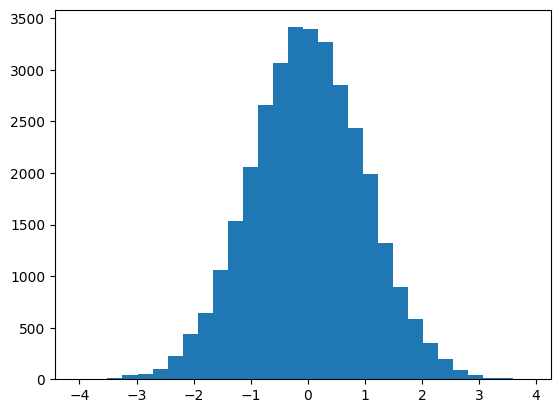

In [7]:
# U = model.unembed.U.weight.detach().numpy()
U = model.embed.E.weight.detach().numpy()
plt.hist(U.flatten(), bins=30)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

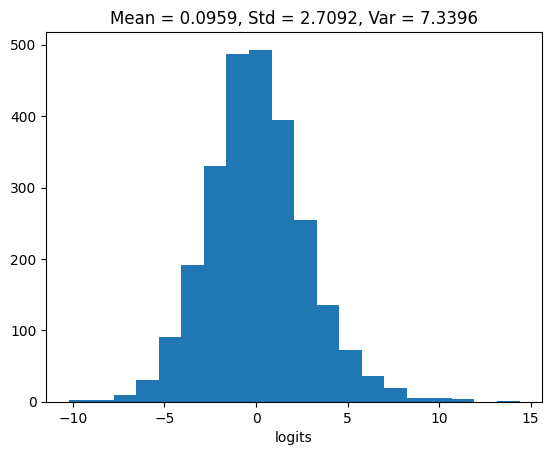

In [8]:
i_batch = 0
variable = 'logits'

var = output[variable].detach().numpy()
mean = var.mean()
std = var.std()


plt.hist(var.flatten(),bins=20)
plt.title(f'Mean = {mean:.4f}, Std = {std:.4f}, Var = {std**2:.4f}')
plt.xlabel(variable)
plt.show

In [63]:
metrics = [LossMetric(name='loss',
                      logits_fn=lambda ctx:ctx.logits_induction[ctx.all],
                      target_fn=lambda ctx:ctx.target[ctx.all],
                      rescale=False)]
evaluator = Evaluator(metrics)
res = evaluator.evaluate(model, batch, loss_fn, distributions['P_b'], distributions['P_u'])

for k,v in res.items():
    print(k,v)

loss 3.7340641021728516
